In [1]:
# ============================================================
# CELL 1 — INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install -q pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

In [2]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import RandomOverSampler

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [3]:
# ============================================================
# CELL 3 — CONNECT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ============================================================
# CELL 4 — LOAD DATASET FROM GOOGLE DRIVE
# ============================================================

import pandas as pd

DATASET_PATH = "/content/drive/MyDrive/Fraud_Detection/creditcardcsvpresent.csv"

df = pd.read_csv(DATASET_PATH)

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

DATASET LOADED SUCCESSFULLY
Rows    : 3075
Columns : 12


In [5]:
# ============================================================
# CELL 5 — CHECK DATASET COLUMNS
# ============================================================

print("Number of rows    :", df.shape[0])
print("Number of columns :", df.shape[1])

print("\nColumns:")
for i, column in enumerate(df.columns, 1):
    print(f"{i}. {column}")

Number of rows    : 3075
Number of columns : 12

Columns:
1. Merchant_id
2. Transaction date
3. Average Amount/transaction/day
4. Transaction_amount
5. Is declined
6. Total Number of declines/day
7. isForeignTransaction
8. isHighRiskCountry
9. Daily_chargeback_avg_amt
10. 6_month_avg_chbk_amt
11. 6-month_chbk_freq
12. isFradulent


In [6]:
# ============================================================
# CELL 6 — FIRST 10 RECORDS
# ============================================================

display(df.head(10))

,Merchant_id,Transaction date,Average Amount/transaction/day,Transaction_amount,Is declined,Total Number of declines/day,isForeignTransaction,isHighRiskCountry,Daily_chargeback_avg_amt,6_month_avg_chbk_amt,6-month_chbk_freq,isFradulent
0,3160040998,NaN,100.0,3000.0,N,5,Y,Y,0,0.0,0,Y
1,3160040998,NaN,100.0,4300.0,N,5,Y,Y,0,0.0,0,Y
2,3160041896,NaN,185.5,4823.0,Y,5,N,N,0,0.0,0,Y
3,3160141996,NaN,185.5,5008.5,Y,8,N,N,0,0.0,0,Y
4,3160241992,NaN,500.0,26000.0,N,0,Y,Y,800,677.2,6,Y
5,3160241992,NaN,500.0,27000.0,N,0,Y,Y,800,677.2,6,Y
6,3160272997,NaN,262.5,11287.5,N,0,N,N,900,345.5,7,Y
7,3162041996,NaN,185.5,11130.0,Y,20,N,N,0,0.0,0,Y
8,3162041996,NaN,185.5,6121.5,Y,20,N,N,0,0.0,0,Y
9,3162041996,NaN,185.5,7049.0,Y,20,N,N,0,0.0,0,Y


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3075 entries, 0 to 3074
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Merchant_id                     3075 non-null   int64  
 1   Transaction date                0 non-null      float64
 2   Average Amount/transaction/day  3075 non-null   float64
 3   Transaction_amount              3075 non-null   float64
 4   Is declined                     3075 non-null   object 
 5   Total Number of declines/day    3075 non-null   int64  
 6   isForeignTransaction            3075 non-null   object 
 7   isHighRiskCountry               3075 non-null   object 
 8   Daily_chargeback_avg_amt        3075 non-null   int64  
 9   6_month_avg_chbk_amt            3075 non-null   float64
 10  6-month_chbk_freq               3075 non-null   int64  
 11  isFradulent                     3075 non-null   object 
dtypes: float64(4), int64(4), object(4)

In [8]:
# ============================================================
# CELL 8 — STATISTICAL ANALYSIS
# ============================================================

print("=" * 70)
print("STATISTICAL ANALYSIS")
print("=" * 70)

# Numerical statistics
numeric_columns = df.select_dtypes(include=np.number).columns

print("\nNumerical Features:")
display(df[numeric_columns].describe().T)

STATISTICAL ANALYSIS

Numerical Features:


,count,mean,std,min,25%,50%,75%,max
Merchant_id,3075.0,5.026634e+09,9.870778e+08,3.160041e+09,4.170814e+09,5.025578e+09,5.889625e+09,6.665906e+09
Transaction date,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Average Amount/transaction/day,3075.0,5.150266e+02,2.919070e+02,4.011527e+00,2.697880e+02,5.025496e+02,7.652728e+02,2.000000e+03
Transaction_amount,3075.0,9.876399e+03,1.013533e+04,0.000000e+00,2.408781e+03,6.698892e+03,1.442257e+04,1.080000e+05
Total Number of declines/day,3075.0,9.573984e-01,2.192391e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01
Daily_chargeback_avg_amt,3075.0,5.573756e+01,2.066348e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.980000e+02
6_month_avg_chbk_amt,3075.0,4.002241e+01,1.559688e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.980000e+02
6-month_chbk_freq,3075.0,3.918699e-01,1.548479e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+00


In [9]:
# ============================================================
# CELL 9 — MISSING VALUE ANALYSIS
# ============================================================

print("=" * 70)
print("MISSING VALUE ANALYSIS")
print("=" * 70)

missing = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Percentage": (missing.values / len(df)) * 100
})

display(missing_table)

print("\nTotal Missing Values:", missing.sum())

MISSING VALUE ANALYSIS


,Column,Missing Values,Percentage
0,Merchant_id,0,0.0
1,Transaction date,3075,100.0
2,Average Amount/transaction/day,0,0.0
3,Transaction_amount,0,0.0
4,Is declined,0,0.0
5,Total Number of declines/day,0,0.0
6,isForeignTransaction,0,0.0
7,isHighRiskCountry,0,0.0
8,Daily_chargeback_avg_amt,0,0.0
9,6_month_avg_chbk_amt,0,0.0



Total Missing Values: 3075


In [10]:
# ============================================================
# CELL 10 — DUPLICATE RECORD ANALYSIS
# ============================================================

duplicate_count = df.duplicated().sum()

print("=" * 70)
print("DUPLICATE RECORD ANALYSIS")
print("=" * 70)

print("Duplicate Records:", duplicate_count)

DUPLICATE RECORD ANALYSIS
Duplicate Records: 0


In [11]:
# ============================================================
# CELL 11 — TARGET CLASS DISTRIBUTION
# ============================================================

target_column = "isFradulent"

print("=" * 70)
print("FRAUD / LEGITIMATE DISTRIBUTION")
print("=" * 70)

class_counts = df[target_column].value_counts()

print("\nClass Counts:")
display(class_counts)

print("\nClass Percentages:")

class_percentages = (
    df[target_column]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(class_percentages)

FRAUD / LEGITIMATE DISTRIBUTION

Class Counts:


,count
isFradulent,
N,2627
Y,448



Class Percentages:


,proportion
isFradulent,
N,85.43
Y,14.57


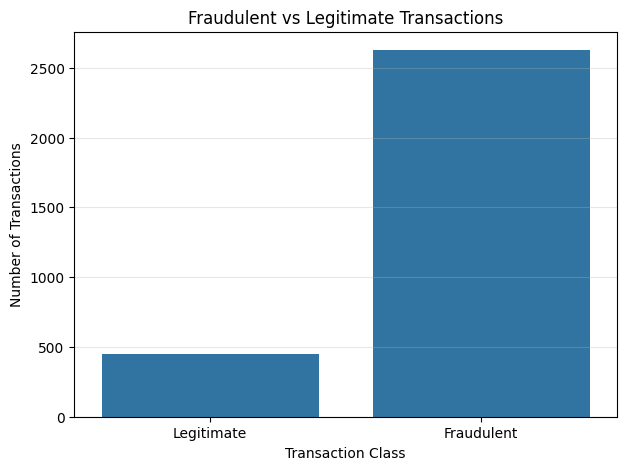

In [12]:
# ============================================================
# CELL 12 — CLASS DISTRIBUTION VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=target_column
)

plt.title("Fraudulent vs Legitimate Transactions")

plt.xlabel("Transaction Class")

plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraudulent"]
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [13]:
# ============================================================
# CELL 13 — FRAUD RATE BY BINARY FEATURES
# ============================================================

binary_features = [
    "Is declined",
    "isForeignTransaction",
    "isHighRiskCountry"
]

print("=" * 70)
print("CHECKING BINARY FEATURES")
print("=" * 70)

# First inspect the target values
print("\nTarget column:", target_column)
print("Target values:")
print(df[target_column].value_counts())

print("\nUnique target values:")
print(df[target_column].unique())


# ------------------------------------------------------------
# Calculate fraud rate safely
# ------------------------------------------------------------

for column in binary_features:

    if column in df.columns:

        print("\n" + "=" * 60)
        print(f"FEATURE: {column}")
        print("=" * 60)

        # Crosstab gives counts without requiring numeric target
        table = pd.crosstab(
            df[column],
            df[target_column]
        )

        print("\nTransaction counts:")
        display(table)

        # Calculate percentages within each feature group
        percentage_table = pd.crosstab(
            df[column],
            df[target_column],
            normalize="index"
        ) * 100

        print("\nPercentage distribution:")
        display(percentage_table.round(2))

CHECKING BINARY FEATURES

Target column: isFradulent
Target values:
isFradulent
N    2627
Y     448
Name: count, dtype: int64

Unique target values:
['Y' 'N']

FEATURE: Is declined

Transaction counts:


isFradulent,N,Y
Is declined,,
N,2618,400
Y,9,48



Percentage distribution:


isFradulent,N,Y
Is declined,,
N,86.75,13.25
Y,15.79,84.21



FEATURE: isForeignTransaction

Transaction counts:


...

isFradulent,N,Y
isForeignTransaction,,
N,94.64,5.36
Y,54.53,45.47



FEATURE: isHighRiskCountry

Transaction counts:


isFradulent,N,Y
isHighRiskCountry,,
N,2625,245
Y,2,203



Percentage distribution:


isFradulent,N,Y
isHighRiskCountry,,
N,91.46,8.54
Y,0.98,99.02


TRANSACTION AMOUNT ANALYSIS

Basic Statistics:


,Transaction_amount
count,3075.000000
mean,9876.399210
std,10135.331016
min,0.000000
25%,2408.781147
50%,6698.891856
75%,14422.568935
max,108000.000000


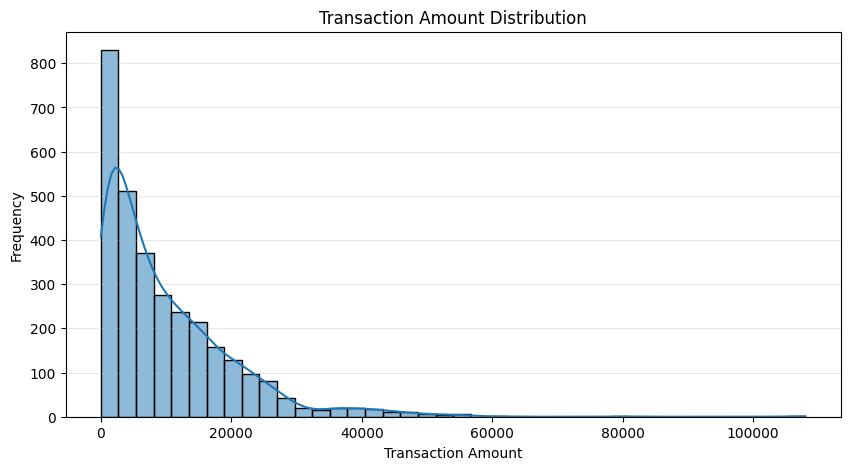

In [14]:
# ============================================================
# CELL 14 — TRANSACTION AMOUNT DISTRIBUTION
# ============================================================

amount_column = "Transaction_amount"

print("=" * 70)
print("TRANSACTION AMOUNT ANALYSIS")
print("=" * 70)

print("\nBasic Statistics:")
display(df[amount_column].describe())

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x=amount_column,
    bins=40,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.xlabel("Transaction Amount")

plt.ylabel("Frequency")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

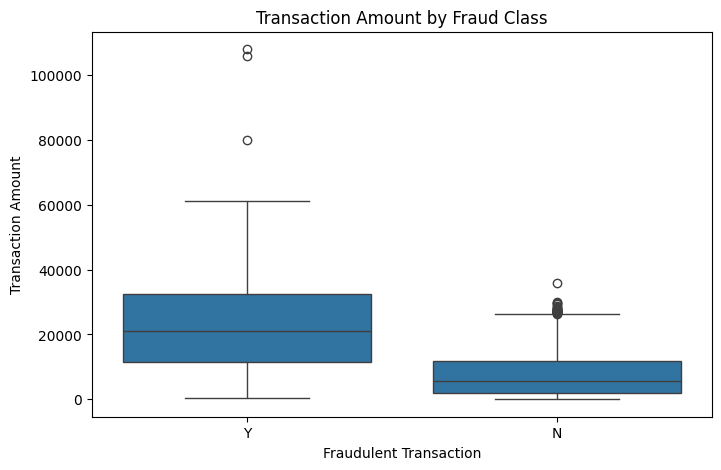

In [15]:
# ============================================================
# CELL 15 — TRANSACTION AMOUNT BY FRAUD CLASS
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x=target_column,
    y=amount_column
)

plt.title("Transaction Amount by Fraud Class")

plt.xlabel("Fraudulent Transaction")

plt.ylabel("Transaction Amount")

plt.show()

In [16]:
# ============================================================
# CELL 16 — FOREIGN TRANSACTION ANALYSIS
# ============================================================

column = "isForeignTransaction"

print("=" * 70)
print("FOREIGN TRANSACTION ANALYSIS")
print("=" * 70)

table = pd.crosstab(
    df[column],
    df[target_column]
)

print("\nTransaction Counts:")
display(table)

percentage_table = pd.crosstab(
    df[column],
    df[target_column],
    normalize="index"
) * 100

print("\nPercentage Distribution:")
display(percentage_table.round(2))

FOREIGN TRANSACTION ANALYSIS

Transaction Counts:


isFradulent,N,Y
isForeignTransaction,,
N,2242,127
Y,385,321



Percentage Distribution:


isFradulent,N,Y
isForeignTransaction,,
N,94.64,5.36
Y,54.53,45.47


In [17]:
# ============================================================
# CELL 17 — DECLINED TRANSACTION ANALYSIS
# ============================================================

column = "Is declined"

print("=" * 70)
print("DECLINED TRANSACTION ANALYSIS")
print("=" * 70)

table = pd.crosstab(
    df[column],
    df[target_column]
)

print("\nTransaction Counts:")
display(table)

percentage_table = pd.crosstab(
    df[column],
    df[target_column],
    normalize="index"
) * 100

print("\nPercentage Distribution:")
display(percentage_table.round(2))

DECLINED TRANSACTION ANALYSIS

Transaction Counts:


isFradulent,N,Y
Is declined,,
N,2618,400
Y,9,48



Percentage Distribution:


isFradulent,N,Y
Is declined,,
N,86.75,13.25
Y,15.79,84.21


In [18]:
# ============================================================
# CELL 18 — CHARGEBACK FEATURE ANALYSIS
# ============================================================

chargeback_features = [
    "Daily_chargeback_avg_amt",
    "6_month_avg_chbk_amt",
    "6-month_chbk_freq"
]

print("=" * 70)
print("CHARGEBACK FEATURE STATISTICS")
print("=" * 70)

display(
    df[chargeback_features].describe().T
)

CHARGEBACK FEATURE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Daily_chargeback_avg_amt,3075.0,55.737561,206.634779,0.0,0.0,0.0,0.0,998.0
6_month_avg_chbk_amt,3075.0,40.022407,155.968840,0.0,0.0,0.0,0.0,998.0
6-month_chbk_freq,3075.0,0.391870,1.548479,0.0,0.0,0.0,0.0,9.0


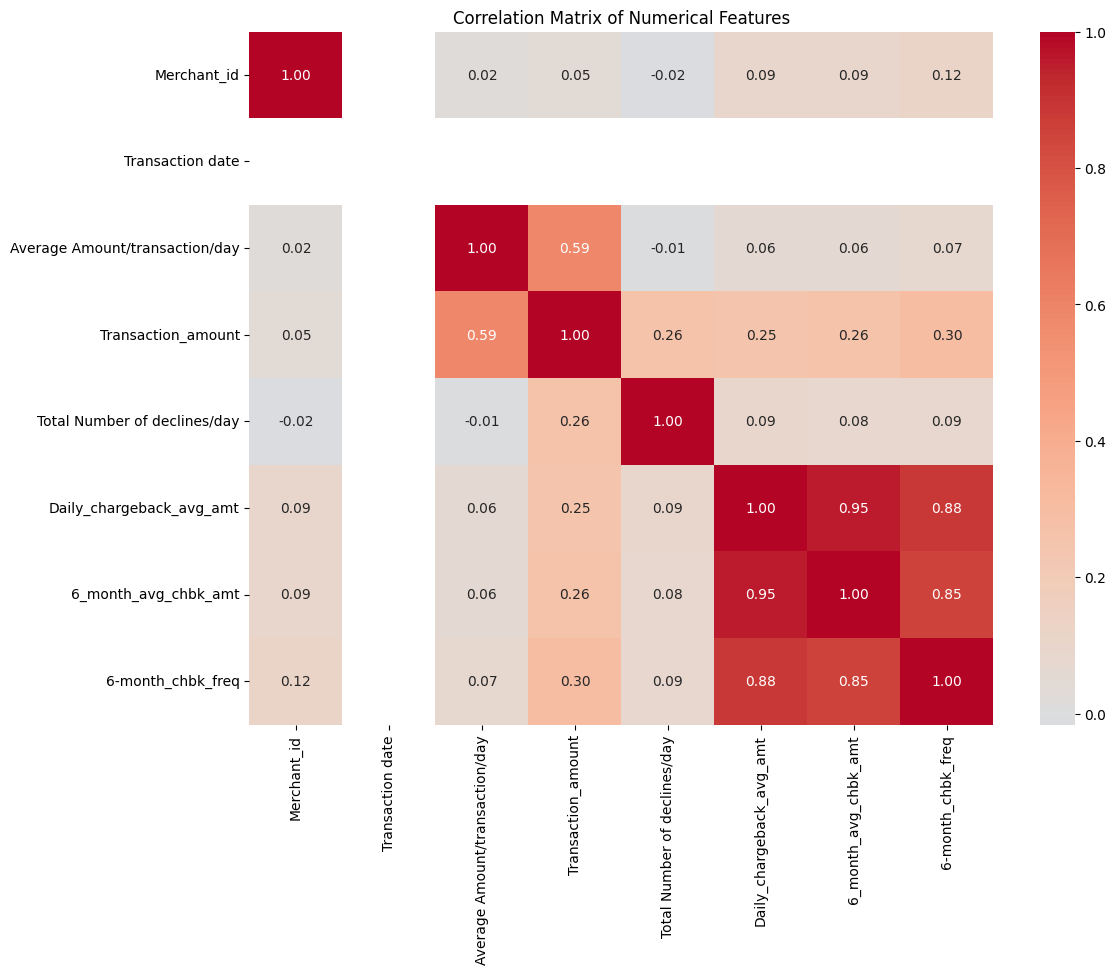

In [19]:
# ============================================================
# CELL 19 — CORRELATION MATRIX
# ============================================================

numeric_df = df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [20]:
# ============================================================
# CELL 20 — FEATURE TYPE & UNIQUE VALUE ANALYSIS
# ============================================================

print("=" * 70)
print("FEATURE TYPE AND UNIQUE VALUE ANALYSIS")
print("=" * 70)

feature_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Unique Values": [df[col].nunique() for col in df.columns],
    "Missing Values": [df[col].isnull().sum() for col in df.columns]
})

display(feature_summary)

FEATURE TYPE AND UNIQUE VALUE ANALYSIS


,Column,Data Type,Unique Values,Missing Values
Merchant_id,Merchant_id,int64,3015,0
Transaction date,Transaction date,float64,0,3075
Average Amount/transaction/day,Average Amount/transaction/day,float64,3016,0
Transaction_amount,Transaction_amount,float64,2973,0
Is declined,Is declined,object,2,0
Total Number of declines/day,Total Number of declines/day,int64,11,0
isForeignTransaction,isForeignTransaction,object,2,0
isHighRiskCountry,isHighRiskCountry,object,2,0
Daily_chargeback_avg_amt,Daily_chargeback_avg_amt,int64,133,0
6_month_avg_chbk_amt,6_month_avg_chbk_amt,float64,146,0


In [21]:
# ============================================================
# CELL 21 — BINARY FEATURE VALUES
# ============================================================

binary_features = [
    "Is declined",
    "isForeignTransaction",
    "isHighRiskCountry"
]

print("=" * 70)
print("BINARY FEATURE VALUES")
print("=" * 70)

for column in binary_features:

    if column in df.columns:

        print(f"\n{column}")
        print("-" * 50)
        print(df[column].value_counts(dropna=False))

BINARY FEATURE VALUES

Is declined
--------------------------------------------------
Is declined
N    3018
Y      57
Name: count, dtype: int64

isForeignTransaction
--------------------------------------------------
isForeignTransaction
N    2369
Y     706
Name: count, dtype: int64

isHighRiskCountry
--------------------------------------------------
isHighRiskCountry
N    2870
Y     205
Name: count, dtype: int64


In [22]:
# ============================================================
# CELL 22 — CONVERT TARGET TO NUMERICAL FORMAT
# ============================================================

print("=" * 70)
print("TARGET CONVERSION")
print("=" * 70)

print("Original target values:")
print(df[target_column].value_counts())

# Convert N/Y into 0/1
df[target_column] = (
    df[target_column]
    .astype(str)
    .str.strip()
    .str.upper()
    .map({
        "N": 0,
        "Y": 1
    })
)

print("\nConverted target values:")
print(df[target_column].value_counts())

print("\nMapping:")
print("0 = Legitimate")
print("1 = Fraudulent")

TARGET CONVERSION
Original target values:
isFradulent
N    2627
Y     448
Name: count, dtype: int64

Converted target values:
isFradulent
0    2627
1     448
Name: count, dtype: int64

Mapping:
0 = Legitimate
1 = Fraudulent


In [23]:
# ============================================================
# CELL 23 — VERIFY TARGET CONVERSION
# ============================================================

print("=" * 70)
print("TARGET VERIFICATION")
print("=" * 70)

print("Unique target values:")
print(df[target_column].unique())

print("\nTarget data type:")
print(df[target_column].dtype)

if df[target_column].isnull().sum() == 0:
    print("\n✓ Target conversion successful.")
else:
    print(
        "\n⚠ WARNING:",
        df[target_column].isnull().sum(),
        "target values could not be converted."
    )

TARGET VERIFICATION
Unique target values:
[1 0]

Target data type:
int64

✓ Target conversion successful.


In [24]:
# ============================================================
# CELL 24 — CONVERT BINARY FEATURES TO 0/1
# ============================================================

binary_features = [
    "Is declined",
    "isForeignTransaction",
    "isHighRiskCountry"
]

for column in binary_features:

    if column in df.columns:

        df[column] = (
            df[column]
            .astype(str)
            .str.strip()
            .str.upper()
            .map({
                "N": 0,
                "Y": 1
            })
        )

print("=" * 70)
print("BINARY FEATURE CONVERSION COMPLETE")
print("=" * 70)

display(df[binary_features].head())

print("\nUnique values:")

for column in binary_features:
    print(column, ":", df[column].unique())

BINARY FEATURE CONVERSION COMPLETE


,Is declined,isForeignTransaction,isHighRiskCountry
0,0,1,1
1,0,1,1
2,1,0,0
3,1,0,0
4,0,1,1



Unique values:
Is declined : [0 1]
isForeignTransaction : [1 0]
isHighRiskCountry : [1 0]


In [25]:
# ============================================================
# CELL 25 — CHECK CONVERTED FEATURES
# ============================================================

print("=" * 70)
print("CONVERSION VALIDATION")
print("=" * 70)

for column in binary_features:

    print(
        f"{column}: "
        f"{df[column].isnull().sum()} invalid/missing values"
    )

CONVERSION VALIDATION
Is declined: 0 invalid/missing values
isForeignTransaction: 0 invalid/missing values
isHighRiskCountry: 0 invalid/missing values


In [26]:
# ============================================================
# CELL 26 — FINAL FEATURE SELECTION
# ============================================================

print("=" * 70)
print("FINAL FEATURE SELECTION")
print("=" * 70)

# Columns that should NOT be used as numerical model features
columns_to_remove = [
    target_column,
    "Merchant_id",
    "Transaction date"
]

# Keep only columns that actually exist
columns_to_remove = [
    col for col in columns_to_remove
    if col in df.columns
]

X = df.drop(
    columns=columns_to_remove
)

y = df[target_column].copy()

print("Removed columns:")
for column in columns_to_remove:
    print(" -", column)

print("\nFinal modelling features:")

for i, column in enumerate(X.columns, 1):
    print(f"{i}. {column}")

print("\nNumber of modelling features:", X.shape[1])

FINAL FEATURE SELECTION
Removed columns:
 - isFradulent
 - Merchant_id
 - Transaction date

Final modelling features:
1. Average Amount/transaction/day
2. Transaction_amount
3. Is declined
4. Total Number of declines/day
5. isForeignTransaction
6. isHighRiskCountry
7. Daily_chargeback_avg_amt
8. 6_month_avg_chbk_amt
9. 6-month_chbk_freq

Number of modelling features: 9


In [27]:
# ============================================================
# CELL 27 — VERIFY FINAL FEATURE TYPES
# ============================================================

print("=" * 70)
print("FINAL FEATURE DATA TYPES")
print("=" * 70)

feature_info = pd.DataFrame({
    "Feature": X.columns,
    "Data Type": X.dtypes.astype(str),
    "Unique Values": [
        X[col].nunique()
        for col in X.columns
    ],
    "Missing Values": [
        X[col].isnull().sum()
        for col in X.columns
    ]
})

display(feature_info)

FINAL FEATURE DATA TYPES


,Feature,Data Type,Unique Values,Missing Values
Average Amount/transaction/day,Average Amount/transaction/day,float64,3016,0
Transaction_amount,Transaction_amount,float64,2973,0
Is declined,Is declined,int64,2,0
Total Number of declines/day,Total Number of declines/day,int64,11,0
isForeignTransaction,isForeignTransaction,int64,2,0
isHighRiskCountry,isHighRiskCountry,int64,2,0
Daily_chargeback_avg_amt,Daily_chargeback_avg_amt,int64,133,0
6_month_avg_chbk_amt,6_month_avg_chbk_amt,float64,146,0
6-month_chbk_freq,6-month_chbk_freq,int64,10,0


In [28]:
# ============================================================
# CELL 28 — FINAL TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 70)
print("FINAL TRAIN / TEST SPLIT")
print("=" * 70)

print("Training samples :", X_train.shape[0])
print("Testing samples  :", X_test.shape[0])

print("\nTraining percentage:",
      round(len(X_train) / len(X) * 100, 2), "%")

print("Testing percentage:",
      round(len(X_test) / len(X) * 100, 2), "%")

print("\nTraining classes:")
display(y_train.value_counts())

print("\nTesting classes:")
display(y_test.value_counts())

FINAL TRAIN / TEST SPLIT
Training samples : 2460
Testing samples  : 615

Training percentage: 80.0 %
Testing percentage: 20.0 %

Training classes:


,count
isFradulent,
0,2102
1,358



Testing classes:


,count
isFradulent,
0,525
1,90


In [29]:
# ============================================================
# CELL 29 — NUMERICAL FEATURES
# ============================================================

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

print("=" * 70)
print("NUMERICAL FEATURES")
print("=" * 70)

for i, column in enumerate(numeric_features, 1):
    print(f"{i}. {column}")

print("\nTotal numerical features:",
      len(numeric_features))

NUMERICAL FEATURES
1. Average Amount/transaction/day
2. Transaction_amount
3. Is declined
4. Total Number of declines/day
5. isForeignTransaction
6. isHighRiskCountry
7. Daily_chargeback_avg_amt
8. 6_month_avg_chbk_amt
9. 6-month_chbk_freq

Total numerical features: 9


In [30]:
# ============================================================
# CELL 30 — FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_test_scaled[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

print("=" * 70)
print("FEATURE SCALING COMPLETE")
print("=" * 70)

print("Scaler fitted ONLY on training data.")

display(
    X_train_scaled.head()
)

FEATURE SCALING COMPLETE
Scaler fitted ONLY on training data.


,Average Amount/transaction/day,Transaction_amount,Is declined,Total Number of declines/day,isForeignTransaction,isHighRiskCountry,Daily_chargeback_avg_amt,6_month_avg_chbk_amt,6-month_chbk_freq
2909,0.762058,-0.539598,-0.139563,2.245817,-0.541014,-0.269003,-0.264973,-0.250208,-0.249441
1492,-0.476675,0.119975,-0.139563,-0.436949,-0.541014,-0.269003,-0.264973,-0.250208,-0.249441
2056,0.830969,0.910371,-0.139563,0.010179,-0.541014,-0.269003,-0.264973,-0.250208,-0.249441
2496,1.163579,-0.384877,-0.139563,-0.436949,-0.541014,-0.269003,-0.264973,-0.250208,-0.249441
547,-1.559486,-0.914013,-0.139563,2.245817,-0.541014,-0.269003,-0.264973,-0.250208,-0.249441


In [31]:
# ============================================================
# CELL 31 — NORMALIZATION
# ============================================================

from sklearn.preprocessing import MinMaxScaler

normalizer = MinMaxScaler()

X_train_normalized = X_train_scaled.copy()
X_test_normalized = X_test_scaled.copy()

X_train_normalized[numeric_features] = (
    normalizer.fit_transform(
        X_train_scaled[numeric_features]
    )
)

X_test_normalized[numeric_features] = (
    normalizer.transform(
        X_test_scaled[numeric_features]
    )
)

print("=" * 70)
print("NORMALIZATION COMPLETE")
print("=" * 70)

display(
    X_train_normalized.head()
)

NORMALIZATION COMPLETE


,Average Amount/transaction/day,Transaction_amount,Is declined,Total Number of declines/day,isForeignTransaction,isHighRiskCountry,Daily_chargeback_avg_amt,6_month_avg_chbk_amt,6-month_chbk_freq
2909,0.366635,0.040891,0.0,0.30,0.0,0.0,0.0,0.0,0.0
1492,0.187941,0.101881,0.0,0.00,0.0,0.0,0.0,0.0,0.0
2056,0.376576,0.174969,0.0,0.05,0.0,0.0,0.0,0.0,0.0
2496,0.424557,0.055198,0.0,0.00,0.0,0.0,0.0,0.0,0.0
547,0.031740,0.006268,0.0,0.30,0.0,0.0,0.0,0.0,0.0


In [32]:
# ============================================================
# CELL 32 — VERIFY NORMALIZATION
# ============================================================

print("=" * 70)
print("NORMALIZATION VERIFICATION")
print("=" * 70)

verification = pd.DataFrame({
    "Minimum": X_train_normalized[numeric_features].min(),
    "Maximum": X_train_normalized[numeric_features].max()
})

display(verification)

NORMALIZATION VERIFICATION


,Minimum,Maximum
Average Amount/transaction/day,0.0,1.0
Transaction_amount,0.0,1.0
Is declined,0.0,1.0
Total Number of declines/day,0.0,1.0
isForeignTransaction,0.0,1.0
isHighRiskCountry,0.0,1.0
Daily_chargeback_avg_amt,0.0,1.0
6_month_avg_chbk_amt,0.0,1.0
6-month_chbk_freq,0.0,1.0


In [33]:
# ============================================================
# CELL33 — RANDOM OVERSAMPLING
# ============================================================

from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(
    random_state=42
)

X_train_ros, y_train_ros = ros.fit_resample(
    X_train_normalized,
    y_train
)

print("=" * 70)
print("RANDOM OVERSAMPLING COMPLETE")
print("=" * 70)

print("Before ROS:")
display(y_train.value_counts())

print("\nAfter ROS:")
display(y_train_ros.value_counts())

RANDOM OVERSAMPLING COMPLETE
Before ROS:


,count
isFradulent,
0,2102
1,358



After ROS:


,count
isFradulent,
0,2102
1,2102


In [34]:
# ============================================================
# CELL 34 — FINAL DATA PREPARATION SUMMARY
# ============================================================

print("=" * 70)
print("FINAL DATA PREPARATION SUMMARY")
print("=" * 70)

print("\nOriginal dataset:")
print("Rows:", len(df))

print("\nTraining data:")
print("Before ROS:", len(X_train))
print("After ROS :", len(X_train_ros))

print("\nTesting data:")
print("Test samples:", len(X_test))

print("\nTraining class distribution AFTER ROS:")
display(y_train_ros.value_counts())

print("\nTesting class distribution:")
display(y_test.value_counts())

print("\nFinal feature count:")
print(X_train_ros.shape[1])

FINAL DATA PREPARATION SUMMARY

Original dataset:
Rows: 3075

Training data:
Before ROS: 2460
After ROS : 4204

Testing data:
Test samples: 615

Training class distribution AFTER ROS:


,count
isFradulent,
0,2102
1,2102



Testing class distribution:


,count
isFradulent,
0,525
1,90



Final feature count:
9


In [35]:
# ============================================================
# CELL 35 — PREPARE DATA FOR HNB
# ============================================================

print("=" * 70)
print("HNB DATA PREPARATION")
print("=" * 70)

# Copy the already-prepared data
X_hnb_train = X_train_ros.copy()
y_hnb_train = y_train_ros.copy()

X_hnb_test = X_test_normalized.copy()
y_hnb_test = y_test.copy()

print("HNB training data shape :", X_hnb_train.shape)
print("HNB testing data shape  :", X_hnb_test.shape)

print("\nTraining class distribution:")
display(y_hnb_train.value_counts())

print("\nTesting class distribution:")
display(y_hnb_test.value_counts())

HNB DATA PREPARATION
HNB training data shape : (4204, 9)
HNB testing data shape  : (615, 9)

Training class distribution:


,count
isFradulent,
0,2102
1,2102



Testing class distribution:


,count
isFradulent,
0,525
1,90


In [36]:
# ============================================================
# CELL 36 — HNB FEATURE LIST
# ============================================================

hnb_features = X_hnb_train.columns.tolist()

print("=" * 70)
print("HNB FEATURES")
print("=" * 70)

for i, feature in enumerate(hnb_features, 1):
    print(f"{i}. {feature}")

print("\nTotal HNB features:", len(hnb_features))

HNB FEATURES
1. Average Amount/transaction/day
2. Transaction_amount
3. Is declined
4. Total Number of declines/day
5. isForeignTransaction
6. isHighRiskCountry
7. Daily_chargeback_avg_amt
8. 6_month_avg_chbk_amt
9. 6-month_chbk_freq

Total HNB features: 9


In [37]:
# ============================================================
# CELL 37 — HNB CLASS PRIOR PROBABILITIES
# ============================================================

print("=" * 70)
print("HNB CLASS PRIOR PROBABILITIES")
print("=" * 70)

class_counts = y_hnb_train.value_counts().sort_index()

total_samples = len(y_hnb_train)

class_priors = class_counts / total_samples

print("Class counts:")
display(class_counts)

print("\nClass prior probabilities:")

for class_value, probability in class_priors.items():

    class_name = (
        "Legitimate"
        if class_value == 0
        else "Fraudulent"
    )

    print(
        f"P({class_name}) = {probability:.4f}"
    )

HNB CLASS PRIOR PROBABILITIES
Class counts:


,count
isFradulent,
0,2102
1,2102



Class prior probabilities:
P(Legitimate) = 0.5000
P(Fraudulent) = 0.5000


In [38]:
# ============================================================
# CELL 38 — HNB DATA DISCRETIZATION
# ============================================================

X_hnb_train_disc = X_hnb_train.copy()
X_hnb_test_disc = X_hnb_test.copy()

constant_features = []
discretized_features = []

for feature in hnb_features:

    unique_values = X_hnb_train[feature].nunique()

    # Constant feature
    if unique_values <= 1:

        constant_features.append(feature)

    # Binary feature
    elif unique_values == 2:

        # Keep binary values as they are
        X_hnb_train_disc[feature] = (
            X_hnb_train[feature].astype(int)
        )

        X_hnb_test_disc[feature] = (
            X_hnb_test[feature].astype(int)
        )

    # Continuous / multi-valued feature
    else:

        try:

            _, bin_edges = pd.qcut(
                X_hnb_train[feature],
                q=5,
                retbins=True,
                duplicates="drop"
            )

            bin_edges[0] = -np.inf
            bin_edges[-1] = np.inf

            X_hnb_train_disc[feature] = pd.cut(
                X_hnb_train[feature],
                bins=bin_edges,
                labels=False,
                include_lowest=True
            )

            X_hnb_test_disc[feature] = pd.cut(
                X_hnb_test[feature],
                bins=bin_edges,
                labels=False,
                include_lowest=True
            )

            discretized_features.append(feature)

        except Exception as e:

            print(
                f"Could not discretize {feature}: {e}"
            )

print("=" * 70)
print("HNB DISCRETIZATION SUMMARY")
print("=" * 70)

print("\nDiscretized features:")
for feature in discretized_features:
    print(" -", feature)

print("\nConstant features:")
for feature in constant_features:
    print(" -", feature)

print("\nNumber of constant features:",
      len(constant_features))

HNB DISCRETIZATION SUMMARY

Discretized features:
 - Average Amount/transaction/day
 - Transaction_amount
 - Total Number of declines/day
 - Daily_chargeback_avg_amt
 - 6_month_avg_chbk_amt
 - 6-month_chbk_freq

Constant features:

Number of constant features: 0


In [39]:
# ============================================================
# CELL 39 — VERIFY HNB FEATURE CATEGORIES
# ============================================================

print("=" * 70)
print("HNB FEATURE CATEGORY CHECK")
print("=" * 70)

for feature in hnb_features:

    print(
        f"{feature}: "
        f"{X_hnb_train_disc[feature].nunique()} unique values"
    )

HNB FEATURE CATEGORY CHECK
Average Amount/transaction/day: 5 unique values
Transaction_amount: 5 unique values
Is declined: 2 unique values
Total Number of declines/day: 3 unique values
isForeignTransaction: 2 unique values
isHighRiskCountry: 2 unique values
Daily_chargeback_avg_amt: 1 unique values
6_month_avg_chbk_amt: 1 unique values
6-month_chbk_freq: 1 unique values


In [40]:
# ============================================================
# CELL 40 — HNB PAIRWISE CONDITIONAL PROBABILITIES
# ============================================================

pairwise_probabilities = {}

classes = sorted(
    y_hnb_train.unique()
)

# Use only features that contain variation
hnb_probability_features = [
    feature
    for feature in hnb_features
    if X_hnb_train_disc[feature].nunique() > 1
]

for i in range(len(hnb_probability_features)):

    feature_i = hnb_probability_features[i]

    for j in range(i + 1, len(hnb_probability_features)):

        feature_j = hnb_probability_features[j]

        pair_key = (
            feature_i,
            feature_j
        )

        pairwise_probabilities[pair_key] = {}

        for class_value in classes:

            class_mask = (
                y_hnb_train == class_value
            )

            subset = X_hnb_train_disc[
                class_mask
            ]

            pair_counts = (
                subset
                .groupby(
                    [feature_i, feature_j]
                )
                .size()
            )

            total = len(subset)

            probabilities = (
                pair_counts / total
            )

            pairwise_probabilities[
                pair_key
            ][class_value] = probabilities

print("=" * 70)
print("PAIRWISE CONDITIONAL PROBABILITIES")
print("=" * 70)

print(
    "Usable features:",
    len(hnb_probability_features)
)

print(
    "Number of feature pairs:",
    len(pairwise_probabilities)
)

PAIRWISE CONDITIONAL PROBABILITIES
Usable features: 6
Number of feature pairs: 15


In [41]:
# ============================================================
# CELL 41 — DISPLAY EXAMPLE PAIRWISE PROBABILITY
# ============================================================

example_pair = list(
    pairwise_probabilities.keys()
)[0]

print("=" * 70)
print("EXAMPLE PAIRWISE CONDITIONAL PROBABILITY")
print("=" * 70)

print("Feature pair:", example_pair)

for class_value in classes:

    class_name = (
        "Legitimate"
        if class_value == 0
        else "Fraudulent"
    )

    print(
        f"\nClass: {class_name}"
    )

    display(
        pairwise_probabilities[
            example_pair
        ][class_value]
        .head(10)
    )

EXAMPLE PAIRWISE CONDITIONAL PROBABILITY
Feature pair: ('Average Amount/transaction/day', 'Transaction_amount')

Class: Legitimate


Average Amount/transaction/day  Transaction_amount
0                               0                     0.160799
                                1                     0.047574
1                               0                     0.076594
                                1                     0.095147
                                2                     0.037108
2                               0                     0.042341
                                1                     0.056613
                                2                     0.077069
                                3                     0.010942
3                               0                     0.035205
dtype: float64


Class: Fraudulent


Average Amount/transaction/day  Transaction_amount
0                               0                     0.060419
                                1                     0.102759
                                2                     0.032826
1                               1                     0.010942
                                2                     0.110371
                                3                     0.068030
2                               2                     0.039962
                                3                     0.107992
                                4                     0.062322
3                               3                     0.060894
dtype: float64

In [42]:
# ============================================================
# CELL 42 — HNB INTERACTION PARAMETERS
# ============================================================

interaction_parameters = {}

for pair_key in pairwise_probabilities:

    feature_i, feature_j = pair_key

    interaction_parameters[pair_key] = {}

    for class_value in classes:

        class_mask = (
            y_hnb_train == class_value
        )

        subset = X_hnb_train_disc[
            class_mask
        ]

        # Individual probabilities
        p_i = (
            subset[feature_i]
            .value_counts(
                normalize=True
            )
        )

        p_j = (
            subset[feature_j]
            .value_counts(
                normalize=True
            )
        )

        pair_prob = (
            pairwise_probabilities[
                pair_key
            ][class_value]
        )

        interactions = {}

        for index, probability in pair_prob.items():

            value_i, value_j = index

            independent_probability = (
                p_i.get(value_i, 1e-10)
                *
                p_j.get(value_j, 1e-10)
            )

            interaction = (
                probability /
                max(
                    independent_probability,
                    1e-10
                )
            )

            interactions[index] = interaction

        interaction_parameters[
            pair_key
        ][class_value] = interactions

print("=" * 70)
print("INTERACTION PARAMETERS CALCULATED")
print("=" * 70)

print(
    "Feature pairs:",
    len(interaction_parameters)
)

INTERACTION PARAMETERS CALCULATED
Feature pairs: 15


In [43]:
# ============================================================
# CELL 43 — INSPECT HNB INTERACTION PARAMETERS
# ============================================================

print("=" * 70)
print("HNB INTERACTION PARAMETER SUMMARY")
print("=" * 70)

interaction_summary = []

for pair_key in interaction_parameters:

    all_values = []

    for class_value in classes:

        values = list(
            interaction_parameters[
                pair_key
            ][class_value].values()
        )

        all_values.extend(values)

    if len(all_values) > 0:

        interaction_summary.append({
            "Feature Pair": str(pair_key),
            "Mean Interaction": np.mean(all_values),
            "Min Interaction": np.min(all_values),
            "Max Interaction": np.max(all_values)
        })

interaction_summary = pd.DataFrame(
    interaction_summary
)

display(
    interaction_summary
    .sort_values(
        "Mean Interaction",
        ascending=False
    )
    .head(15)
)

HNB INTERACTION PARAMETER SUMMARY


,Feature Pair,Mean Interaction,Min Interaction,Max Interaction
11,"('Is declined', 'isHighRiskCountry')",38.353584,0.649412,262.750000
8,"('Transaction_amount', 'isHighRiskCountry')",2.644393,0.741174,27.657895
14,"('isForeignTransaction', 'isHighRiskCountry')",2.146692,0.645712,6.937294
0,"('Average Amount/transaction/day', 'Transactio...",1.630200,0.380813,5.228856
5,"('Transaction_amount', 'Is declined')",1.286016,0.383129,6.914474
4,"('Average Amount/transaction/day', 'isHighRisk...",1.264323,0.871555,5.228856
10,"('Is declined', 'isForeignTransaction')",1.216053,0.713000,2.601485
9,"('Is declined', 'Total Number of declines/day')",1.062555,0.460359,1.602134
1,"('Average Amount/transaction/day', 'Is declined')",1.052307,0.639294,1.960821
7,"('Transaction_amount', 'isForeignTransaction')",1.031375,0.668914,1.460483


In [44]:
# ============================================================
# CELL 44 — FINAL HNB PREPARATION CHECK
# ============================================================

print("=" * 70)
print("FINAL HNB PREPARATION CHECK")
print("=" * 70)

# Recalculate constant features directly from current data
constant_features = [
    feature
    for feature in hnb_features
    if X_hnb_train_disc[feature].nunique(dropna=False) <= 1
]

# Recalculate usable features
hnb_probability_features = [
    feature
    for feature in hnb_features
    if feature not in constant_features
]

# Recalculate number of pairs
number_of_pairs = (
    len(hnb_probability_features)
    * (len(hnb_probability_features) - 1)
    // 2
)

print("\nOriginal features:", len(hnb_features))

print("Constant features:", len(constant_features))

print("Usable HNB features:",
      len(hnb_probability_features))

print("Pairwise combinations:",
      number_of_pairs)

print("\nConstant features:")

if len(constant_features) == 0:
    print(" - None")
else:
    for feature in constant_features:
        print(" -", feature)

print("\nUsable HNB features:")

for feature in hnb_probability_features:
    print(" -", feature)

FINAL HNB PREPARATION CHECK

Original features: 9
Constant features: 3
Usable HNB features: 6
Pairwise combinations: 15

Constant features:
 - Daily_chargeback_avg_amt
 - 6_month_avg_chbk_amt
 - 6-month_chbk_freq

Usable HNB features:
 - Average Amount/transaction/day
 - Transaction_amount
 - Is declined
 - Total Number of declines/day
 - isForeignTransaction
 - isHighRiskCountry


In [45]:
# ============================================================
# CELL 45 — HNB PREDICTION FUNCTION
# ============================================================

def hnb_predict(
    X_data,
    class_priors,
    pairwise_probabilities,
    hnb_probability_features,
    smoothing=1e-6
):
    """
    Hidden Naive Bayes prediction using pairwise
    conditional probabilities.

    0 = Legitimate
    1 = Fraudulent
    """

    predictions = []

    for _, row in X_data.iterrows():

        class_scores = {}

        for class_value in class_priors.index:

            # Start with log prior probability
            score = np.log(
                class_priors[class_value]
                + smoothing
            )

            pair_count = 0

            # Evaluate feature pairs
            for i in range(
                len(hnb_probability_features)
            ):

                feature_i = (
                    hnb_probability_features[i]
                )

                for j in range(
                    i + 1,
                    len(hnb_probability_features)
                ):

                    feature_j = (
                        hnb_probability_features[j]
                    )

                    pair_key = (
                        feature_i,
                        feature_j
                    )

                    value_i = row[feature_i]
                    value_j = row[feature_j]

                    probability_table = (
                        pairwise_probabilities[
                            pair_key
                        ][class_value]
                    )

                    try:

                        probability = (
                            probability_table
                            .get(
                                (value_i, value_j),
                                smoothing
                            )
                        )

                    except Exception:

                        probability = smoothing

                    probability = max(
                        probability,
                        smoothing
                    )

                    score += np.log(
                        probability
                    )

                    pair_count += 1

            # Average pairwise contribution
            if pair_count > 0:

                score = (
                    score / (pair_count + 1)
                )

            class_scores[class_value] = score

        # Select class with highest score
        predicted_class = max(
            class_scores,
            key=class_scores.get
        )

        predictions.append(
            predicted_class
        )

    return np.array(predictions)


print("=" * 70)
print("HNB PREDICTION FUNCTION CREATED")
print("=" * 70)

print("Number of HNB features:",
      len(hnb_probability_features))

print("Number of feature pairs:",
      len(pairwise_probabilities))

print("HNB prediction function is ready.")

HNB PREDICTION FUNCTION CREATED
Number of HNB features: 6
Number of feature pairs: 15
HNB prediction function is ready.


In [46]:
# ============================================================
# CELL 46 — HNB TEST PREDICTIONS
# ============================================================

print("=" * 70)
print("HNB TESTING / INFERENCE")
print("=" * 70)

y_pred_hnb = hnb_predict(
    X_hnb_test_disc,
    class_priors,
    pairwise_probabilities,
    hnb_probability_features
)

print("HNB prediction completed successfully.")

print("\nNumber of test samples:",
      len(y_hnb_test))

print("Number of predictions:",
      len(y_pred_hnb))

print("\nPredicted class distribution:")

predicted_distribution = pd.Series(
    y_pred_hnb
).value_counts().sort_index()

display(predicted_distribution)

print("\nActual class distribution:")

display(
    y_hnb_test.value_counts().sort_index()
)

HNB TESTING / INFERENCE
HNB prediction completed successfully.

Number of test samples: 615
Number of predictions: 615

Predicted class distribution:


,count
0,504
1,111



Actual class distribution:


,count
isFradulent,
0,525
1,90


In [47]:
# ============================================================
# CELL 47 — HNB CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

cm_hnb = confusion_matrix(
    y_hnb_test,
    y_pred_hnb
)

print("=" * 70)
print("HNB CONFUSION MATRIX")
print("=" * 70)

print("\nConfusion Matrix:")
print(cm_hnb)

tn, fp, fn, tp = cm_hnb.ravel()

print("\nTrue Negatives  (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives  (TP):", tp)

HNB CONFUSION MATRIX

Confusion Matrix:
[[495  30]
 [  9  81]]

True Negatives  (TN): 495
False Positives (FP): 30
False Negatives (FN): 9
True Positives  (TP): 81


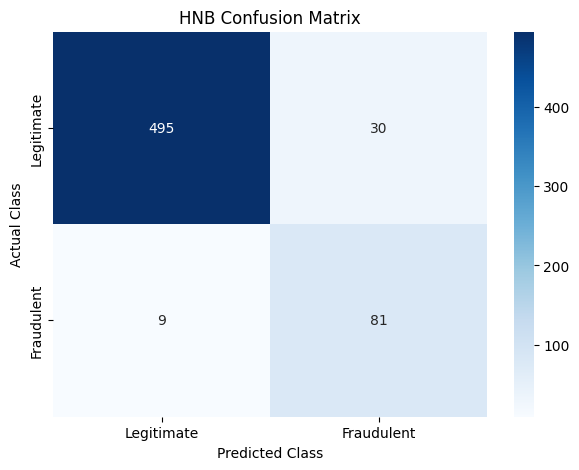

In [48]:
# ============================================================
# CELL 48 — HNB CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_hnb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraudulent"],
    yticklabels=["Legitimate", "Fraudulent"]
)

plt.title("HNB Confusion Matrix")

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.show()

In [49]:
# ============================================================
# CELL 49 — HNB PERFORMANCE METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_hnb = accuracy_score(
    y_hnb_test,
    y_pred_hnb
)

precision_hnb = precision_score(
    y_hnb_test,
    y_pred_hnb,
    zero_division=0
)

recall_hnb = recall_score(
    y_hnb_test,
    y_pred_hnb,
    zero_division=0
)

f1_hnb = f1_score(
    y_hnb_test,
    y_pred_hnb,
    zero_division=0
)

print("=" * 70)
print("HNB PERFORMANCE")
print("=" * 70)

print(f"Accuracy  : {accuracy_hnb:.4f}")
print(f"Precision : {precision_hnb:.4f}")
print(f"Recall    : {recall_hnb:.4f}")
print(f"F1 Score  : {f1_hnb:.4f}")

HNB PERFORMANCE
Accuracy  : 0.9366
Precision : 0.7297
Recall    : 0.9000
F1 Score  : 0.8060


In [50]:
# ============================================================
# CELL 50 — HNB METRICS IN PERCENTAGE
# ============================================================

print("=" * 70)
print("HNB PERFORMANCE (%)")
print("=" * 70)

print(
    f"Accuracy  : {accuracy_hnb * 100:.2f}%"
)

print(
    f"Precision : {precision_hnb * 100:.2f}%"
)

print(
    f"Recall    : {recall_hnb * 100:.2f}%"
)

print(
    f"F1 Score  : {f1_hnb * 100:.2f}%"
)

HNB PERFORMANCE (%)
Accuracy  : 93.66%
Precision : 72.97%
Recall    : 90.00%
F1 Score  : 80.60%


In [51]:
# ============================================================
# CELL 51 — HNB CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print("=" * 70)
print("HNB CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_hnb_test,
        y_pred_hnb,
        target_names=[
            "Legitimate",
            "Fraudulent"
        ],
        zero_division=0
    )
)

HNB CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate       0.98      0.94      0.96       525
  Fraudulent       0.73      0.90      0.81        90

    accuracy                           0.94       615
   macro avg       0.86      0.92      0.88       615
weighted avg       0.95      0.94      0.94       615



In [52]:
# ============================================================
# CELL 52 — STORE HNB RESULTS
# ============================================================

hnb_results = {
    "Model": "Hidden Naive Bayes (HNB)",
    "Accuracy": accuracy_hnb,
    "Precision": precision_hnb,
    "Recall": recall_hnb,
    "F1 Score": f1_hnb
}

hnb_results_df = pd.DataFrame(
    [hnb_results]
)

print("=" * 70)
print("HNB RESULTS SUMMARY")
print("=" * 70)

display(hnb_results_df)

HNB RESULTS SUMMARY


,Model,Accuracy,Precision,Recall,F1 Score
0,Hidden Naive Bayes (HNB),0.936585,0.72973,0.9,0.80597


In [53]:
# ============================================================
# CELL 53 — INSTALL BBN LIBRARY
# ============================================================

!pip install -q pgmpy

print("pgmpy installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 10.8 MB/s eta 0:00:00
pgmpy installed successfully.


In [54]:
# ============================================================
# CELL 54 — IMPORT BBN LIBRARIES
# ============================================================

import pgmpy

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

print("=" * 70)
print("BBN LIBRARIES")
print("=" * 70)

print("pgmpy version:", pgmpy.__version__)
print("BBN libraries imported successfully.")

BBN LIBRARIES
pgmpy version: 1.1.2
BBN libraries imported successfully.


In [55]:
# ============================================================
# CELL 55 — PREPARE BBN DATA
# ============================================================

bbn_features = hnb_probability_features.copy()

bbn_train = X_hnb_train_disc[
    bbn_features
].copy()

bbn_train[target_column] = (
    y_hnb_train.values
)

bbn_test = X_hnb_test_disc[
    bbn_features
].copy()

bbn_test[target_column] = (
    y_hnb_test.values
)

print("=" * 70)
print("BBN DATA PREPARATION")
print("=" * 70)

print("BBN features:", len(bbn_features))

print("\nFeatures:")
for feature in bbn_features:
    print(" -", feature)

print("\nTraining shape:", bbn_train.shape)
print("Testing shape :", bbn_test.shape)

BBN DATA PREPARATION
BBN features: 6

Features:
 - Average Amount/transaction/day
 - Transaction_amount
 - Is declined
 - Total Number of declines/day
 - isForeignTransaction
 - isHighRiskCountry

Training shape: (4204, 7)
Testing shape : (615, 7)


In [56]:
# ============================================================
# CELL 56 — VERIFY BBN STATES
# ============================================================

print("=" * 70)
print("BBN STATE SPACE")
print("=" * 70)

for column in bbn_train.columns:

    print(
        f"\n{column}"
    )

    print(
        "Training states:",
        sorted(
            bbn_train[column]
            .dropna()
            .unique()
            .tolist()
        )
    )

BBN STATE SPACE

Average Amount/transaction/day
Training states: [0, 1, 2, 3, 4]

Transaction_amount
Training states: [0, 1, 2, 3, 4]

Is declined
Training states: [0, 1]

Total Number of declines/day
Training states: [0, 1, 2]

isForeignTransaction
Training states: [0, 1]

isHighRiskCountry
Training states: [0, 1]

isFradulent
Training states: [0, 1]


In [57]:
# ============================================================
# CELL 57 — DEFINE BBN STRUCTURE
# ============================================================

edges = [
    (
        "Average Amount/transaction/day",
        "Transaction_amount"
    ),

    (
        "Transaction_amount",
        "isFradulent"
    ),

    (
        "Is declined",
        "isFradulent"
    ),

    (
        "Total Number of declines/day",
        "Is declined"
    ),

    (
        "isForeignTransaction",
        "isFradulent"
    ),

    (
        "isHighRiskCountry",
        "isForeignTransaction"
    ),

    (
        "isHighRiskCountry",
        "isFradulent"
    )
]

print("=" * 70)
print("BBN NETWORK STRUCTURE")
print("=" * 70)

for parent, child in edges:
    print(
        f"{parent}  →  {child}"
    )

print("\nNumber of directed edges:", len(edges))

BBN NETWORK STRUCTURE
Average Amount/transaction/day  →  Transaction_amount
Transaction_amount  →  isFradulent
Is declined  →  isFradulent
Total Number of declines/day  →  Is declined
isForeignTransaction  →  isFradulent
isHighRiskCountry  →  isForeignTransaction
isHighRiskCountry  →  isFradulent

Number of directed edges: 7


In [58]:
# ============================================================
# CELL 58 — CREATE BBN MODEL
# ============================================================

bbn_model = DiscreteBayesianNetwork(
    edges
)

print("=" * 70)
print("BBN MODEL CREATED")
print("=" * 70)

print("Number of nodes:",
      len(bbn_model.nodes()))

print("Number of edges:",
      len(bbn_model.edges()))

print("\nNodes:")
for node in bbn_model.nodes():
    print(" -", node)

print("\nEdges:")
for edge in bbn_model.edges():
    print(" -", edge)

BBN MODEL CREATED
Number of nodes: 7
Number of edges: 7

Nodes:
 - Average Amount/transaction/day
 - Transaction_amount
 - isFradulent
 - Is declined
 - Total Number of declines/day
 - isForeignTransaction
 - isHighRiskCountry

Edges:
 - ('Average Amount/transaction/day', 'Transaction_amount')
 - ('Transaction_amount', 'isFradulent')
 - ('Is declined', 'isFradulent')
 - ('Total Number of declines/day', 'Is declined')
 - ('isForeignTransaction', 'isFradulent')
 - ('isHighRiskCountry', 'isForeignTransaction')
 - ('isHighRiskCountry', 'isFradulent')


BBN NETWORK VISUALIZATION


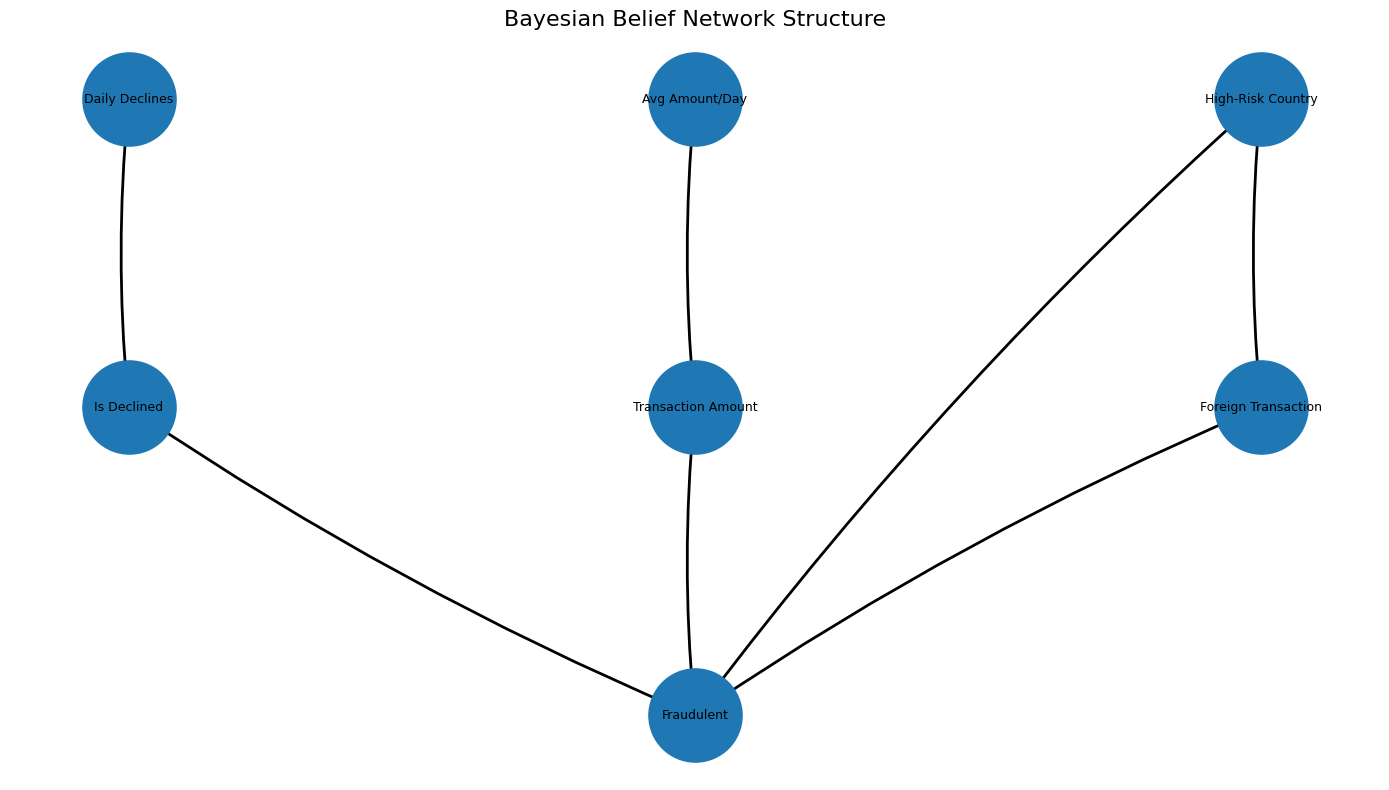


BBN visualization generated successfully.


In [59]:
# ============================================================
# CELL 59 — VISUALIZE BBN STRUCTURE
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt

print("=" * 70)
print("BBN NETWORK VISUALIZATION")
print("=" * 70)

# Create a fresh directed graph from the BBN
G = nx.DiGraph()

G.add_edges_from(
    list(bbn_model.edges())
)

# Short labels for cleaner visualization
short_labels = {
    "Average Amount/transaction/day": "Avg Amount/Day",
    "Transaction_amount": "Transaction Amount",
    "Is declined": "Is Declined",
    "Total Number of declines/day": "Daily Declines",
    "isForeignTransaction": "Foreign Transaction",
    "isHighRiskCountry": "High-Risk Country",
    "isFradulent": "Fraudulent"
}

# Manually position nodes
pos = {
    "Average Amount/transaction/day": (0, 2),
    "Transaction_amount": (0, 1),
    "Total Number of declines/day": (-3, 2),
    "Is declined": (-3, 1),
    "isHighRiskCountry": (3, 2),
    "isForeignTransaction": (3, 1),
    "isFradulent": (0, 0)
}

plt.figure(figsize=(14, 8))

# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=4500
)

# Draw directed edges
nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowsize=25,
    width=2,
    connectionstyle="arc3,rad=0.05"
)

# Draw short labels
nx.draw_networkx_labels(
    G,
    pos,
    labels=short_labels,
    font_size=9
)

plt.title(
    "Bayesian Belief Network Structure",
    fontsize=16
)

plt.axis("off")
plt.tight_layout()

plt.show()

print("\nBBN visualization generated successfully.")

In [60]:
# ============================================================
# CELL 60 — BBN PARAMETER LEARNING
# ============================================================

from pgmpy.estimators import MaximumLikelihoodEstimator

print("=" * 70)
print("BBN PARAMETER LEARNING")
print("=" * 70)

# Initialize Maximum Likelihood Estimator
mle_estimator = MaximumLikelihoodEstimator(
    model=bbn_model,
    data=bbn_train
)

print("Maximum Likelihood Estimator initialized.")

# Estimate CPDs for all nodes
bbn_cpds = mle_estimator.get_parameters(
    n_jobs=1
)

print("CPDs estimated successfully.")

# Add learned CPDs to the Bayesian Network
bbn_model.add_cpds(
    *bbn_cpds
)

print("CPDs added to the BBN.")

print("\nNumber of CPDs:",
      len(bbn_model.get_cpds()))

print("\nBBN parameter learning completed successfully.")

BBN PARAMETER LEARNING
Maximum Likelihood Estimator initialized.
CPDs estimated successfully.
CPDs added to the BBN.

Number of CPDs: 7

BBN parameter learning completed successfully.


In [61]:
# ============================================================
# CELL 61 — VALIDATE BBN MODEL
# ============================================================

print("=" * 70)
print("BBN MODEL VALIDATION")
print("=" * 70)

try:

    model_valid = bbn_model.check_model()

    print(
        "BBN model valid:",
        model_valid
    )

except Exception as e:

    print("BBN validation failed:")
    print(e)

BBN MODEL VALIDATION
BBN model valid: True


In [62]:
# ============================================================
# CELL 62 — DISPLAY BBN CONDITIONAL PROBABILITY TABLES
# ============================================================

print("=" * 70)
print("BBN CONDITIONAL PROBABILITY DISTRIBUTIONS")
print("=" * 70)

for cpd in bbn_model.get_cpds():

    print("\n" + "=" * 60)
    print(cpd)

BBN CONDITIONAL PROBABILITY DISTRIBUTIONS

+-----------------------------------+----------+
| Average Amount/transaction/day(0) | 0.202188 |
+-----------------------------------+----------+
| Average Amount/transaction/day(1) | 0.199096 |
+-----------------------------------+----------+
| Average Amount/transaction/day(2) | 0.19862  |
+-----------------------------------+----------+
| Average Amount/transaction/day(3) | 0.200048 |
+-----------------------------------+----------+
| Average Amount/transaction/day(4) | 0.200048 |
+-----------------------------------+----------+

+--------------------------------+-----+
| Average Amount/transaction/day | ... |
+--------------------------------+-----+
| Transaction_amount(0)          | ... |
+--------------------------------+-----+
| Transaction_amount(1)          | ... |
+--------------------------------+-----+
| Transaction_amount(2)          | ... |
+--------------------------------+-----+
| Transaction_amount(3)          | ... |
+------

In [63]:
# ============================================================
# CELL 63 — FRAUD NODE CPD
# ============================================================

print("=" * 70)
print("FRAUD NODE CONDITIONAL PROBABILITY TABLE")
print("=" * 70)

fraud_cpd = bbn_model.get_cpds(
    target_column
)

print(fraud_cpd)

FRAUD NODE CONDITIONAL PROBABILITY TABLE
+----------------------+-----+-------------------------+
| Is declined          | ... | Is declined(1)          |
+----------------------+-----+-------------------------+
| Transaction_amount   | ... | Transaction_amount(4)   |
+----------------------+-----+-------------------------+
| isForeignTransaction | ... | isForeignTransaction(1) |
+----------------------+-----+-------------------------+
| isHighRiskCountry    | ... | isHighRiskCountry(1)    |
+----------------------+-----+-------------------------+
| isFradulent(0)       | ... | 0.025                   |
+----------------------+-----+-------------------------+
| isFradulent(1)       | ... | 0.975                   |
+----------------------+-----+-------------------------+


In [64]:
# ============================================================
# CELL 64 — BBN INFERENCE ENGINE
# ============================================================

from pgmpy.inference import VariableElimination

print("=" * 70)
print("BBN INFERENCE ENGINE")
print("=" * 70)

bbn_inference = VariableElimination(
    bbn_model
)

print("Variable Elimination inference engine created successfully.")

BBN INFERENCE ENGINE
Variable Elimination inference engine created successfully.


In [65]:
# ============================================================
# CELL 65 — BBN TEST INFERENCE
# ============================================================

print("=" * 70)
print("BBN TESTING / INFERENCE")
print("=" * 70)

y_pred_bbn = []

# Features used as evidence
evidence_features = bbn_features.copy()

for index, row in bbn_test.iterrows():

    evidence = {}

    # Build evidence from the test transaction
    for feature in evidence_features:

        value = row[feature]

        # Skip missing values
        if pd.notna(value):
            evidence[feature] = int(value)

    try:

        # Calculate posterior probability
        result = bbn_inference.query(
            variables=[target_column],
            evidence=evidence,
            show_progress=False
        )

        # Probability of fraud
        fraud_probability = result.values[1]

        # Classify using 0.5 threshold
        if fraud_probability >= 0.5:
            prediction = 1
        else:
            prediction = 0

    except Exception as e:

        print(
            f"Inference failed for index {index}: {e}"
        )

        prediction = 0

    y_pred_bbn.append(prediction)


y_pred_bbn = np.array(
    y_pred_bbn
)

print("\nBBN inference completed successfully.")

print("Number of test samples:",
      len(y_hnb_test))

print("Number of BBN predictions:",
      len(y_pred_bbn))

print("\nPredicted class distribution:")

display(
    pd.Series(
        y_pred_bbn
    ).value_counts().sort_index()
)

print("\nActual class distribution:")

display(
    y_hnb_test.value_counts().sort_index()
)

BBN TESTING / INFERENCE

BBN inference completed successfully.
Number of test samples: 615
Number of BBN predictions: 615

Predicted class distribution:


,count
0,528
1,87



Actual class distribution:


,count
isFradulent,
0,525
1,90


In [66]:
# ============================================================
# CELL 66 — BBN CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

cm_bbn = confusion_matrix(
    y_hnb_test,
    y_pred_bbn
)

print("=" * 70)
print("BBN CONFUSION MATRIX")
print("=" * 70)

print("\nConfusion Matrix:")
print(cm_bbn)

tn_bbn, fp_bbn, fn_bbn, tp_bbn = (
    cm_bbn.ravel()
)

print("\nTrue Negatives  (TN):", tn_bbn)
print("False Positives (FP):", fp_bbn)
print("False Negatives (FN):", fn_bbn)
print("True Positives  (TP):", tp_bbn)

BBN CONFUSION MATRIX

Confusion Matrix:
[[505  20]
 [ 23  67]]

True Negatives  (TN): 505
False Positives (FP): 20
False Negatives (FN): 23
True Positives  (TP): 67


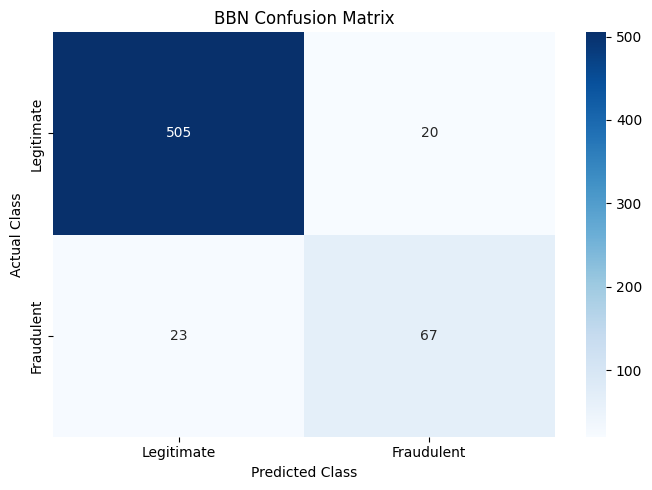

In [67]:
# ============================================================
# CELL 67 — BBN CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_bbn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Legitimate",
        "Fraudulent"
    ],
    yticklabels=[
        "Legitimate",
        "Fraudulent"
    ]
)

plt.title(
    "BBN Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.tight_layout()

plt.show()

In [68]:
# ============================================================
# CELL 68 — BBN PERFORMANCE METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_bbn = accuracy_score(
    y_hnb_test,
    y_pred_bbn
)

precision_bbn = precision_score(
    y_hnb_test,
    y_pred_bbn,
    zero_division=0
)

recall_bbn = recall_score(
    y_hnb_test,
    y_pred_bbn,
    zero_division=0
)

f1_bbn = f1_score(
    y_hnb_test,
    y_pred_bbn,
    zero_division=0
)

print("=" * 70)
print("BBN PERFORMANCE")
print("=" * 70)

print(
    f"Accuracy  : {accuracy_bbn:.4f}"
)

print(
    f"Precision : {precision_bbn:.4f}"
)

print(
    f"Recall    : {recall_bbn:.4f}"
)

print(
    f"F1 Score  : {f1_bbn:.4f}"
)

BBN PERFORMANCE
Accuracy  : 0.9301
Precision : 0.7701
Recall    : 0.7444
F1 Score  : 0.7571


In [69]:
# ============================================================
# CELL 69 — BBN PERFORMANCE (%)
# ============================================================

print("=" * 70)
print("BBN PERFORMANCE (%)")
print("=" * 70)

print(
    f"Accuracy  : {accuracy_bbn * 100:.2f}%"
)

print(
    f"Precision : {precision_bbn * 100:.2f}%"
)

print(
    f"Recall    : {recall_bbn * 100:.2f}%"
)

print(
    f"F1 Score  : {f1_bbn * 100:.2f}%"
)

BBN PERFORMANCE (%)
Accuracy  : 93.01%
Precision : 77.01%
Recall    : 74.44%
F1 Score  : 75.71%


In [70]:
# ============================================================
# CELL 70 — BBN CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print("=" * 70)
print("BBN CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_hnb_test,
        y_pred_bbn,
        target_names=[
            "Legitimate",
            "Fraudulent"
        ],
        zero_division=0
    )
)

BBN CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate       0.96      0.96      0.96       525
  Fraudulent       0.77      0.74      0.76        90

    accuracy                           0.93       615
   macro avg       0.86      0.85      0.86       615
weighted avg       0.93      0.93      0.93       615



In [71]:
# ============================================================
# CELL 71 — STORE BBN RESULTS
# ============================================================

bbn_results = {
    "Model": "Bayesian Belief Network (BBN)",
    "Accuracy": accuracy_bbn,
    "Precision": precision_bbn,
    "Recall": recall_bbn,
    "F1 Score": f1_bbn
}

bbn_results_df = pd.DataFrame(
    [bbn_results]
)

print("=" * 70)
print("BBN RESULTS SUMMARY")
print("=" * 70)

display(bbn_results_df)

BBN RESULTS SUMMARY


,Model,Accuracy,Precision,Recall,F1 Score
0,Bayesian Belief Network (BBN),0.930081,0.770115,0.744444,0.757062
